# Olympics Data Analysis

Dataset: https://www.kaggle.com/heesoo37/120-years-of-olympic-history-athletes-and-results

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [34]:
df = pd.read_csv('athlete_events.csv')
region_df = pd.read_csv('noc_regions.csv')

print("athlete_events shape:", df.shape)
print("noc_regions shape:", region_df.shape)
df.head()

athlete_events shape: (271116, 15)
noc_regions shape: (230, 3)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [35]:
def preprocess(df, region_df):
    df = df[df['Season'] == 'Summer']
    df = df.merge(region_df, on='NOC', how='left')
    df.drop_duplicates(inplace=True)
    df = pd.concat([df, pd.get_dummies(df['Medal'])], axis=1)
    return df

df = preprocess(df, region_df)
print("Preprocessed shape:", df.shape)
df.head()

Preprocessed shape: (221167, 20)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,False,False,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,False,False,False


In [36]:
def fetch_medal_tally(df, year='Overall', country='Overall'):
    medal_df = df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
    flag = 0
    if year == 'Overall' and country == 'Overall':
        temp_df = medal_df
    elif year == 'Overall' and country != 'Overall':
        flag = 1
        temp_df = medal_df[medal_df['region'] == country]
    elif year != 'Overall' and country == 'Overall':
        temp_df = medal_df[medal_df['Year'] == int(year)]
    else:
        temp_df = medal_df[(medal_df['Year'] == int(year)) & (medal_df['region'] == country)]

    if flag == 1:
        x = temp_df.groupby('Year').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Year').reset_index()
    else:
        x = temp_df.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False).reset_index()

    x['Total'] = x['Gold'] + x['Silver'] + x['Bronze']
    for col in ['Gold', 'Silver', 'Bronze', 'Total']:
        x[col] = x[col].astype(int)
    return x

In [ ]:
overall_tally = fetch_medal_tally(df)
print("Overall Medal Tally")
overall_tally.head(20)

Overall Medal Tally


,region,Gold,Silver,Bronze,Total
0,USA,1035,802,708,2545
1,Russia,592,498,487,1577
2,Germany,444,457,491,1392
3,UK,278,317,300,895
4,France,234,256,287,777
5,China,228,163,154,545
6,Italy,219,191,198,608
7,Hungary,178,154,172,504
8,Sweden,150,175,188,513
9,Australia,150,171,197,518


In [ ]:
# Medal Tally for a specific year 
year_tally = fetch_medal_tally(df, year=2004)
print("Medal Tally")
year_tally.head(20)

Medal Tally


,region,Gold,Silver,Bronze,Total
0,USA,36,39,26,101
1,China,32,18,14,64
2,Russia,28,26,36,90
3,Australia,17,16,17,50
4,Japan,16,9,12,37
5,Germany,13,16,20,49
6,France,11,9,13,33
7,Italy,10,11,11,32
8,UK,9,9,12,30
9,Cuba,9,7,11,27


In [39]:
india_tally = fetch_medal_tally(df, country='India')
print("=== India Overall Performance ===")
india_tally

=== India Overall Performance ===


,Year,Gold,Silver,Bronze,Total
0,1900,0,2,0,2
1,1920,0,0,0,0
2,1924,0,0,0,0
3,1928,1,0,0,1
4,1932,1,0,0,1
5,1936,1,0,0,1
6,1948,1,0,0,1
7,1952,1,0,1,2
8,1956,1,0,0,1
9,1960,0,1,0,1


In [40]:
top20 = overall_tally.head(20)
fig = px.bar(
    top20, x='region', y=['Gold', 'Silver', 'Bronze'],
    title='Top 20 Countries — Medal Count',
    barmode='group', height=500,
    color_discrete_sequence=['#FFD700', '#C0C0C0', '#CD7F32']
)
fig.show()

In [41]:
editions  = df['Year'].unique().shape[0] - 1
cities    = df['City'].unique().shape[0]
sports    = df['Sport'].unique().shape[0]
events    = df['Event'].unique().shape[0]
athletes  = df['Name'].unique().shape[0]
nations   = df['region'].unique().shape[0]

stats = pd.DataFrame({
    'Metric': ['Editions', 'Host Cities', 'Sports', 'Events', 'Nations', 'Athletes'],
    'Count':  [editions, cities, sports, events, nations, athletes]
})
print("=== Top-Level Statistics ===")
stats

=== Top-Level Statistics ===


,Metric,Count
0,Editions,28
1,Host Cities,23
2,Sports,52
3,Events,651
4,Nations,206
5,Athletes,116122


In [42]:
def data_over_time(df, col):
    result = (
        df.drop_duplicates(['Year', col])['Year']
        .value_counts()
        .reset_index()
        .sort_values('Year')
    )
    result.columns = ['Edition', col]
    return result

nations_over_time = data_over_time(df, 'region')
fig = px.line(nations_over_time, x='Edition', y='region',
              title='Participating Nations over the Years',
              markers=True)
fig.show()

In [43]:
events_over_time = data_over_time(df, 'Event')
fig = px.line(events_over_time, x='Edition', y='Event',
              title='Events over the Years', markers=True)
fig.show()

In [44]:
athletes_over_time = data_over_time(df, 'Name')
fig = px.line(athletes_over_time, x='Edition', y='Name',
              title='Athletes over the Years', markers=True)
fig.show()

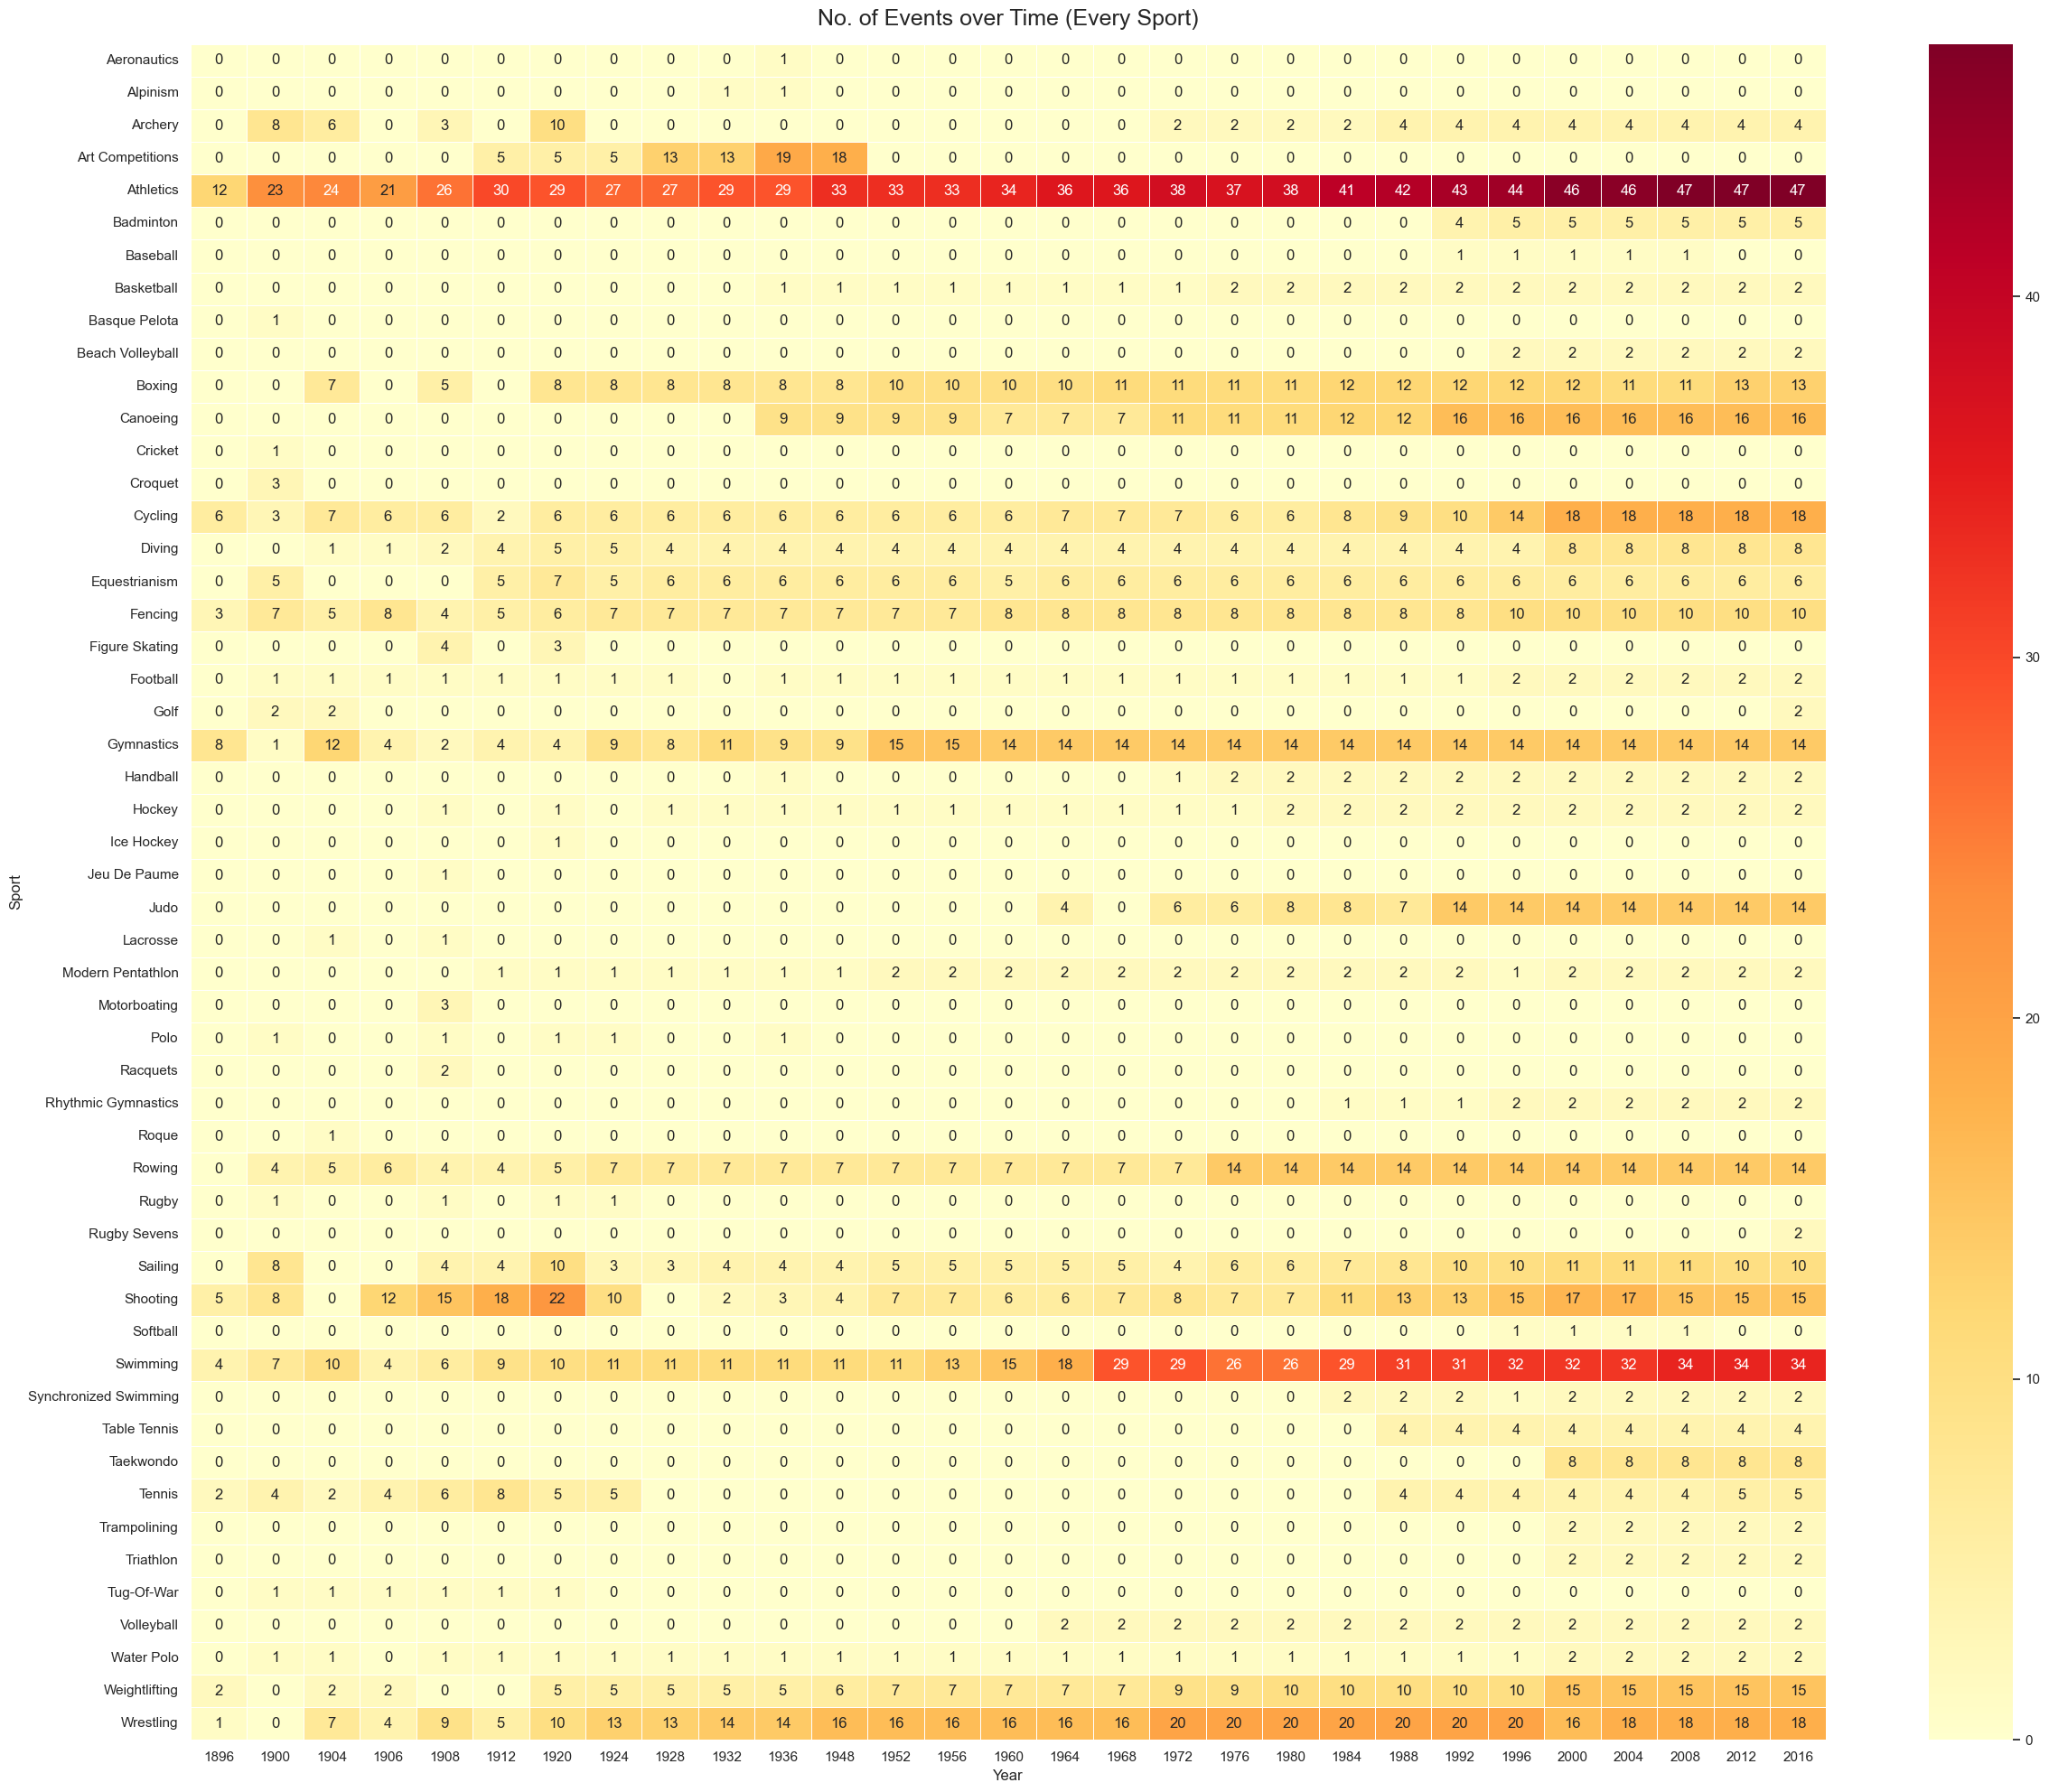

In [45]:
x = df.drop_duplicates(['Year', 'Sport', 'Event'])
pivot = x.pivot_table(index='Sport', columns='Year', values='Event', aggfunc='count').fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(25, 20))
sns.heatmap(pivot, annot=True, fmt='d', linewidths=0.5, ax=ax, cmap='YlOrRd')
ax.set_title('No. of Events over Time (Every Sport)', fontsize=18, pad=15)
plt.tight_layout()
plt.show()

In [46]:
# Most Successful Athletes
def most_successful(df, sport='Overall'):
    temp_df = df.dropna(subset=['Medal'])
    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]
    x = (
        temp_df['Name'].value_counts()
        .reset_index()
        .head(15)
        .merge(df, left_on='Name', right_on='Name', how='left')
        [['Name', 'count', 'Sport', 'region']]
        .drop_duplicates('Name')
    )
    x.rename(columns={'count': 'Medals'}, inplace=True)
    return x

print("Top 15 Most Successful Athletes (Overall)")
most_successful(df)

Top 15 Most Successful Athletes (Overall)


,Name,Medals,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
97,Takashi Ono,13,Gymnastics,Japan
130,Edoardo Mangiarotti,13,Fencing,Italy
144,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
157,Aleksey Yuryevich Nemov,12,Gymnastics,Russia
178,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
195,Birgit Fischer-Schmidt,12,Canoeing,Germany


In [47]:
print("Top 15 Most Successful Swimmers")
most_successful(df, sport='Swimming')

Top 15 Most Successful Swimmers


,Name,Medals,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
47,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
60,Ryan Steven Lochte,12,Swimming,USA
74,Natalie Anne Coughlin (-Hall),12,Swimming,USA
86,"Matthew Nicholas ""Matt"" Biondi",11,Swimming,USA
98,Mark Andrew Spitz,11,Swimming,USA
110,"Gary Wayne Hall, Jr.",10,Swimming,USA
120,Franziska van Almsick,10,Swimming,Germany
143,Shirley Frances Babashoff,9,Swimming,USA


In [48]:
def yearwise_medal_tally(df, country):
    temp_df = df.dropna(subset=['Medal'])
    temp_df = temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
    new_df = temp_df[temp_df['region'] == country]
    final_df = new_df.groupby('Year').count()['Medal'].reset_index()
    return final_df

# Change country below to explore different countries
selected_country = 'USA'

country_df = yearwise_medal_tally(df, selected_country)
fig = px.line(country_df, x='Year', y='Medal',
              title=f'{selected_country} — Medal Tally over the Years',
              markers=True)
fig.show()

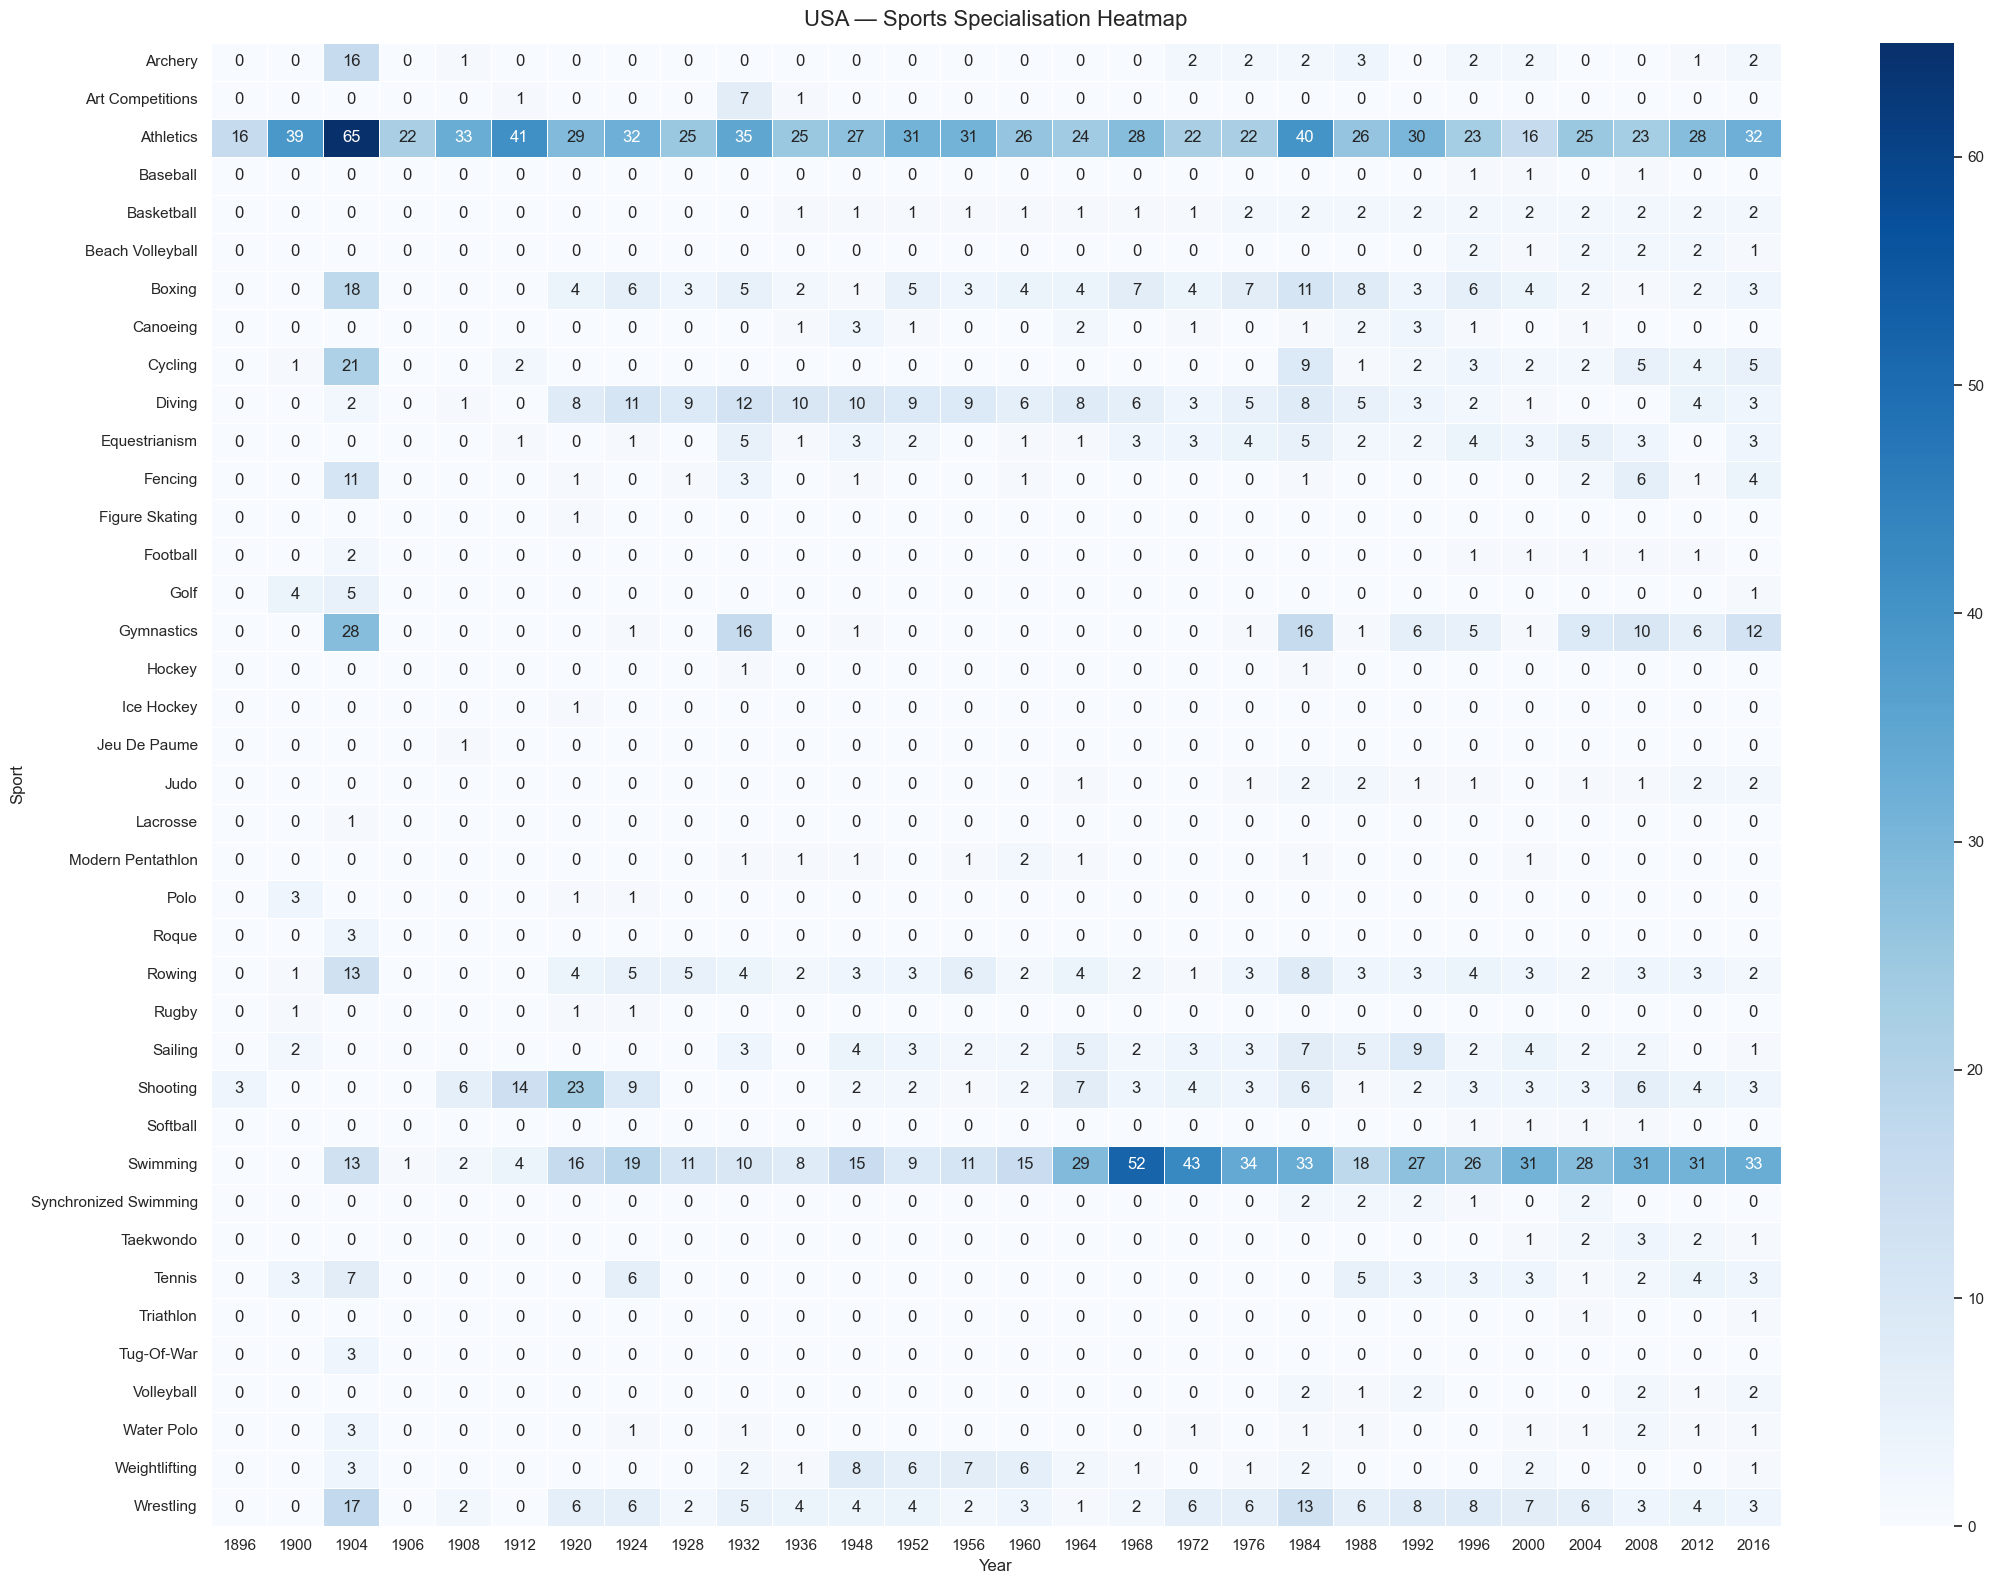

In [49]:
def country_event_heatmap(df, country):
    temp_df = df.dropna(subset=['Medal'])
    temp_df = temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
    new_df = temp_df[temp_df['region'] == country]
    pt = new_df.pivot_table(index='Sport', columns='Year', values='Medal', aggfunc='count').fillna(0)
    return pt

pt = country_event_heatmap(df, selected_country)
fig, ax = plt.subplots(figsize=(22, 16))
sns.heatmap(pt, annot=True, fmt='.0f', linewidths=0.4, ax=ax, cmap='Blues')
ax.set_title(f'{selected_country} — Sports Specialisation Heatmap', fontsize=16, pad=12)
plt.tight_layout()
plt.show()

In [50]:
def most_successful_countrywise(df, country):
    temp_df = df.dropna(subset=['Medal'])
    temp_df = temp_df[temp_df['region'] == country]
    x = (
        temp_df['Name'].value_counts()
        .reset_index()
        .head(10)
        .merge(df, left_on='Name', right_on='Name', how='left')
        [['Name', 'count', 'Sport']]
        .drop_duplicates('Name')
    )
    x.rename(columns={'count': 'Medals'}, inplace=True)
    return x

print(f"=== Top 10 Athletes of {selected_country} ===")
most_successful_countrywise(df, selected_country)

=== Top 10 Athletes of USA ===


,Name,Medals,Sport
0,"Michael Fred Phelps, II",28,Swimming
30,Ryan Steven Lochte,12,Swimming
44,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming
61,Natalie Anne Coughlin (-Hall),12,Swimming
73,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming
86,"Matthew Nicholas ""Matt"" Biondi",11,Swimming
98,Carl Townsend Osburn,11,Shooting
114,Mark Andrew Spitz,11,Swimming
126,"Raymond Clarence ""Ray"" Ewry",10,Athletics
136,"Frederick Carlton ""Carl"" Lewis",10,Athletics


In [51]:

selected_country_2 = 'India'

country_df2 = yearwise_medal_tally(df, selected_country_2)
fig = px.line(country_df2, x='Year', y='Medal',
              title=f'{selected_country_2} — Medal Tally over the Years',
              markers=True)
fig.show()

print(f"\n=== Top 10 Athletes of {selected_country_2} ===")
most_successful_countrywise(df, selected_country_2)


=== Top 10 Athletes of India ===


,Name,Medals,Sport
0,Udham Singh Kular,4,Hockey
4,Leslie Walter Claudius,4,Hockey
8,Shankar Pillay Laxman,3,Hockey
11,Ranganathan Francis,3,Hockey
14,Richard James Allen,3,Hockey
17,Balbir Singh,3,Hockey
20,Harbinder Singh Chimni,3,Hockey
23,"Balbir Singh Dosanjh, Sr.",3,Hockey
26,"Victor John ""V. J."" Peter",3,Hockey
29,Dhyan Chand Bais,3,Hockey


---
## 6. Athlete-wise Analysis

In [52]:
athlete_df = df.drop_duplicates(subset=['Name', 'region'])

x1 = athlete_df['Age'].dropna()
x2 = athlete_df[athlete_df['Medal'] == 'Gold']['Age'].dropna()
x3 = athlete_df[athlete_df['Medal'] == 'Silver']['Age'].dropna()
x4 = athlete_df[athlete_df['Medal'] == 'Bronze']['Age'].dropna()

fig = ff.create_distplot(
    [x1, x2, x3, x4],
    ['Overall Age', 'Gold Medalist', 'Silver Medalist', 'Bronze Medalist'],
    show_hist=False, show_rug=False
)
fig.update_layout(title='Distribution of Age by Medal Type',
                  autosize=False, width=1000, height=600)
fig.show()

This graph does provide an average but it fails to skewedness since most sports have similar specifications and requirements and hence the extraordinary cases get foreshadowed (like taekwondo)

In [53]:
famous_sports = [
    'Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
    'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
    'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
    'Water Polo', 'Hockey', 'Rowing', 'Fencing',
    'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
    'Tennis', 'Golf', 'Softball', 'Archery',
    'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
    'Rhythmic Gymnastics', 'Rugby Sevens',
    'Beach Volleyball', 'Triathlon', 'Rugby', 'Polo', 'Ice Hockey'
]

x, name = [], []
for sport in famous_sports:
    temp = athlete_df[athlete_df['Sport'] == sport]
    ages = temp[temp['Medal'] == 'Gold']['Age'].dropna()
    if len(ages) > 1:         
        x.append(ages)
        name.append(sport)

fig = ff.create_distplot(x, name, show_hist=False, show_rug=False)
fig.update_layout(title='Age Distribution by Sport (Gold Medalists)',
                  autosize=False, width=1100, height=650)
fig.show()

Rhythmic gymnastics shows the highest count of young participants which is due to their flexibity and low susceptibility to damage caused by high speed movements which would force their body in an uncomfortably difficult state.

Most of the games seem to target young audience more but taekwondo seems to be more winnable for older people. This is because mastering taekwondo takes a lot of time and dedication. hence, even the participation seems to skip younglings.  

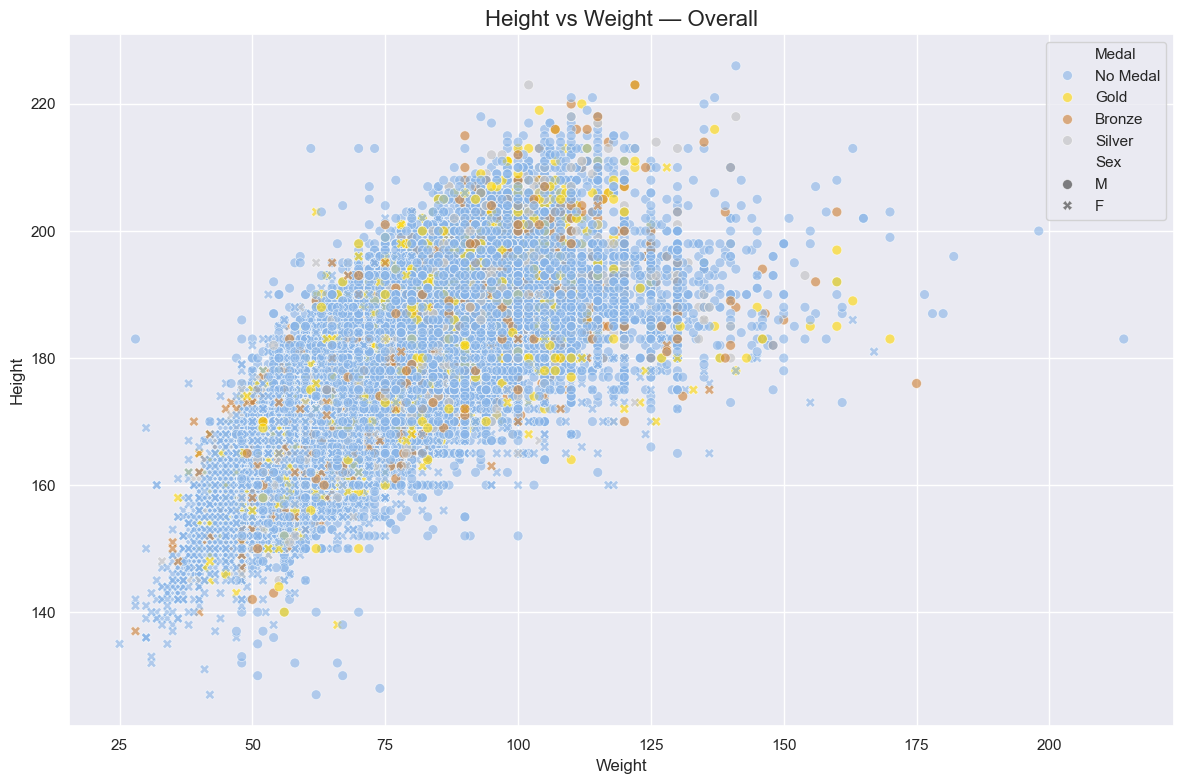

In [54]:
def weight_v_height(df, sport='Overall'):
    athlete_df = df.drop_duplicates(subset=['Name', 'region']).copy()
    athlete_df['Medal'] = athlete_df['Medal'].fillna('No Medal')
    if sport != 'Overall':
        return athlete_df[athlete_df['Sport'] == sport]
    return athlete_df

sport_choice = 'Overall'   
temp_df = weight_v_height(df, sport_choice)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=temp_df, x='Weight', y='Height',
    hue='Medal', style='Sex', s=50, alpha=0.6,
    palette={'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32', 'No Medal': '#88B4E7'},
    ax=ax
)
ax.set_title(f'Height vs Weight — {sport_choice}', fontsize=16)
plt.tight_layout()
plt.show()

If we ignore the outliers, it seems that the three medalist tiers like to stick around. They appear to be together in multiple instances. This plot cannot infer a "perfect fitness" level but we can see that all medalists have a certain degree of similarity. Maybe these could act as an idealistic benchmark for those trying to improvise their fitness levels.

In [55]:
def men_vs_women(df):
    athlete_df = df.drop_duplicates(subset=['Name', 'region'])
    men   = athlete_df[athlete_df['Sex'] == 'M'].groupby('Year').count()['Name'].reset_index()
    women = athlete_df[athlete_df['Sex'] == 'F'].groupby('Year').count()['Name'].reset_index()
    final = men.merge(women, on='Year', how='left')
    final.rename(columns={'Name_x': 'Male', 'Name_y': 'Female'}, inplace=True)
    final['Female'] = final['Female'].fillna(0)
    return final

final = men_vs_women(df)
fig = px.line(final, x='Year', y=['Male', 'Female'],
              title='Men vs Women Participation over the Years',
              markers=True)
fig.update_layout(autosize=False, width=1000, height=600)
fig.show()

The plot for men's participation is jagged but it shows a pattern similar to women's. 
This indicates an unavoidable event like war, economic crisis, etc.
But men's participation has dropped significantly in past few years and it appears that both men and women would be equally invested in olympics soon as a solid competition of equals. 